In [1]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

Connecting to SQL Server

In [2]:

engine = create_engine(
    "mssql+pyodbc://DESKTOP-IJ9P2EK\SQLEXPRESS/Chinook_Dataset"
    "?driver=ODBC+Driver+17+for+SQL+Server"
)

Inserting Tables into SQL

In [ ]:
df = pd.read_csv(
    r"C:\Users\Bilal Traders\Desktop\Chinook_Dataset\Album.csv"
)

df.to_sql(
    'Album',
    engine,
    if_exists='replace', 
    index=False
)

In [ ]:
df1 = pd.read_csv('Artist.csv')
df1.to_sql(
    'Artist',
    engine,
    if_exists='replace',
    index=False
)

In [ ]:
df2 = pd.read_csv('Customer.csv')
df2.to_sql(
    'Customer',
    engine,
    if_exists='replace',
    index=False
)

59

In [ ]:
df3 = pd.read_csv('Employee.csv')
df3.to_sql(
    'Employee',
    engine,
    if_exists='replace',
    index=False
)

8

In [ ]:
df4 = pd.read_csv('Genre.csv')
df4.to_sql(
    'Genre',
    engine,
    if_exists='replace',
    index=False
)

25

In [ ]:
df5 = pd.read_csv('Invoice.csv')
df5.to_sql(
    'Invoice',
    engine,
    if_exists='replace',
    index=False
)

179

In [ ]:
df6 = pd.read_csv('InvoiceLine.csv')
df6.to_sql(
    'InvoiceLine',
    engine,
    if_exists='replace',
    index=False
)

145

In [ ]:
df7 = pd.read_csv('MediaType.csv')
df7.to_sql(
    'MediaType',
    engine,
    if_exists='replace',
    index=False
)

5

In [ ]:
df8 = pd.read_csv('Playlist.csv')
df8.to_sql(
    'Playlist',
    engine,
    if_exists='replace',
    index=False
)

18

In [ ]:
df9 = pd.read_csv('PlaylistTrack.csv')
df9.to_sql(
    'PlaylistTrack',
    engine,
    if_exists='replace',
    index=False
)

715

In [ ]:
df10 = pd.read_csv('Track.csv')
df10.to_sql(
    'Track',
    engine,
    if_exists='replace',
    index=False
)

8

Handling Missing values

In [ ]:
Customer = pd.read_sql("SELECT * FROM Customer", engine)
Customer['PostalCode'] = Customer['PostalCode'].fillna(00000)
Customer['Company'] = Customer['Company'].fillna("Individual")
Customer['State'] = Customer['State'].fillna("Unknown")
Customer['Phone'] = Customer['Phone'].fillna("N/A")
Customer['Fax'] = Customer['Fax'].fillna("N/A")
# Check missing values
print(Customer.isnull().sum())

CustomerId      0
FirstName       0
LastName        0
Company         0
Address         0
City            0
State           0
Country         0
PostalCode      0
Phone           0
Fax             0
Email           0
SupportRepId    0
dtype: int64


In [ ]:
Track = pd.read_sql("SELECT * FROM Track", engine)
Track['Composer'] = Track["Composer"].fillna("Unknown")
# Check missing values
print(Track.isnull().sum())

TrackId         0
Name            0
AlbumId         0
MediaTypeId     0
GenreId         0
Composer        0
Milliseconds    0
Bytes           0
UnitPrice       0
dtype: int64


Visualization

Top 15 Tracks

In [4]:
query = """SELECT TOP 15
    il.TrackId, 
    t.Name AS TrackName, 
    SUM(il.Quantity) AS TotalUnitsSold,
    SUM(il.UnitPrice * il.Quantity) AS Total_Revenue
FROM 
    InvoiceLine il 
inner join
    Track t ON il.TrackID = t.TrackId
GROUP BY 
    il.TrackId, 
    t.Name
order by
    Total_Revenue desc"""

Dataframe = pd.read_sql(query,engine)




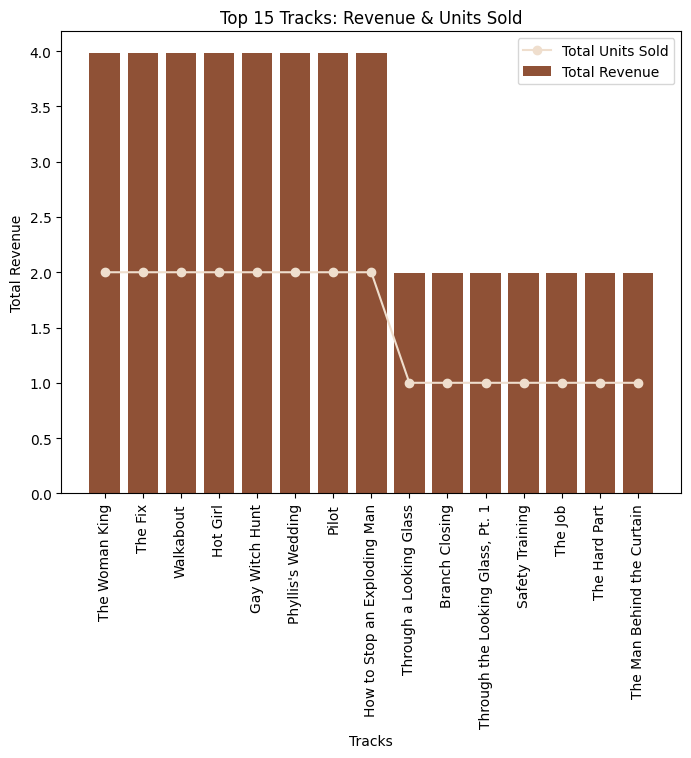

In [5]:
fig, ax = plt.subplots(figsize=(8,6))

# Bar chart (Revenue)
ax.bar(Dataframe["TrackName"], 
       Dataframe["Total_Revenue"],color='#8f5136',label='Total Revenue')

# Line chart (Units Sold) — same axis
ax.plot(Dataframe["TrackName"], 
        Dataframe["TotalUnitsSold"], color = '#efdecd',
        marker='o', label='Total Units Sold')

ax.set_xlabel("Tracks")
ax.set_ylabel("Total Revenue")
ax.set_title("Top 15 Tracks: Revenue & Units Sold")
plt.xticks(rotation=90)
ax.legend(loc='upper right')
plt.show()


Top 10 Countries by Revenue

In [6]:
query1 = """SELECT top 10
    BillingCountry,
    COUNT(DISTINCT CustomerId) AS NumCustomers,  
    COUNT(*) AS NumInvoices,                      
    SUM(Total) AS TotalRevenue                   
FROM Invoice
GROUP BY BillingCountry
ORDER BY TotalRevenue DESC;"""

Dataframe = pd.read_sql(query1,engine)

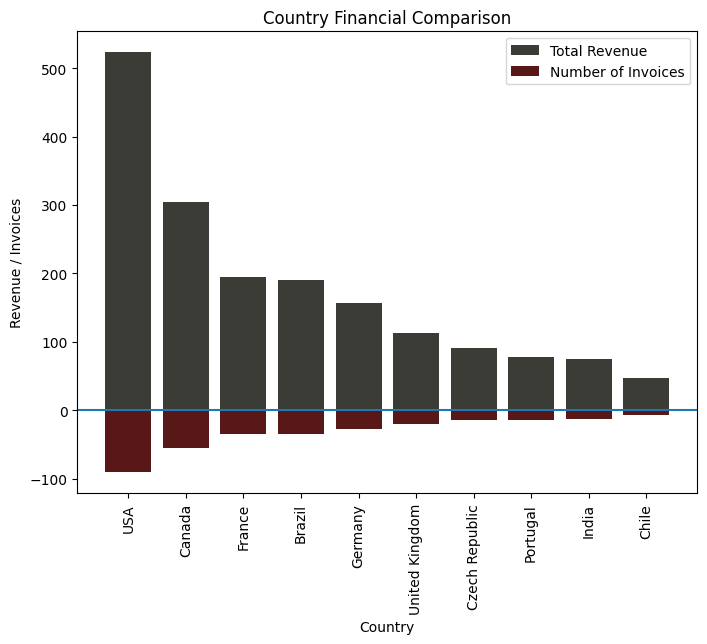

In [7]:
fig, ax = plt.subplots(figsize=(8,6))

# Revenue (positive bars)
ax.bar(Dataframe["BillingCountry"],
       Dataframe["TotalRevenue"], color = '#3b3c36',
       label="Total Revenue")

# Invoices (negative bars)
ax.bar(Dataframe["BillingCountry"],
       -Dataframe["NumInvoices"], color = '#581818',
       label="Number of Invoices")

ax.set_xlabel("Country")
ax.set_ylabel("Revenue / Invoices")
ax.set_title("Country Financial Comparison")

plt.xticks(rotation=90)
ax.axhline(0) 
ax.legend()
plt.show()


Top 5 Artist

In [8]:
query2 = """SELECT top 5
    al.ArtistId, ar.Name as Artist_Name,
sum (il.UnitPrice * il.Quantity) as Total_Sales,
count (Distinct al.Title) as No_of_Album
from Album al 
inner join Artist ar on al.ArtistID = ar.ArtistId
inner join Track t on t.AlbumId = al.AlbumId
inner join InvoiceLine il on il.TrackID = t.TrackId
Group by al.ArtistId, ar.Name
order by Total_Sales desc"""

Dataframe = pd.read_sql(query2,engine)

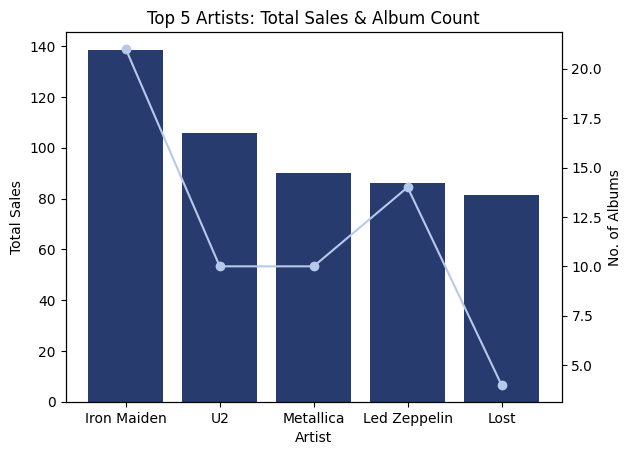

In [9]:
top5 = Dataframe.head(5)

fig, ax1 = plt.subplots()

ax1.bar(top5['Artist_Name'], top5['Total_Sales'], color = "#283B6E")
ax1.set_xlabel("Artist")
ax1.set_ylabel("Total Sales")

ax2 = ax1.twinx()
ax2.plot(top5['Artist_Name'], top5['No_of_Album'], marker='o', color = "#b7c9eb")
ax2.set_ylabel("No. of Albums")


plt.title("Top 5 Artists: Total Sales & Album Count")
plt.show()


Track Occurrence in Playlist

In [10]:
query3 = """SELECT 
    t.Name as Track ,al.Title as Album_Name,
count (distinct pt.PlaylistId) as Playlist_Count
from Track t 
inner join Album al on t.AlbumId = al.AlbumId
inner join Artist ar on al.ArtistId = ar.ArtistId
inner join PlaylistTrack pt on pt.TrackId = t.TrackId
group by t.Name, al.Title
order by Playlist_Count desc"""

Dataframe = pd.read_sql(query3,engine)

In [11]:
distribution = Dataframe['Playlist_Count'].value_counts().sort_index(ascending=False)
print(distribution)

Playlist_Count
5      41
4      70
3    1445
2    1941
Name: count, dtype: int64


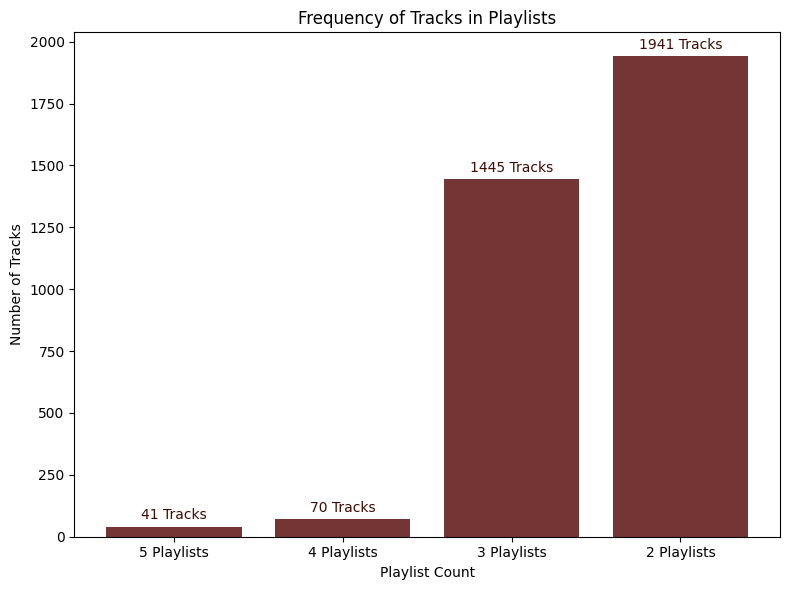

In [12]:
distribution = Dataframe['Playlist_Count'].value_counts().sort_index(ascending=False)

x_labels = [f"{count} Playlists" for count in distribution.index]
y_values = distribution.values

plt.figure(figsize=(8,6))
bars = plt.bar(x_labels, y_values, color='#733635')

plt.xlabel("Playlist Count")
plt.ylabel("Number of Tracks")
plt.title("Frequency of Tracks in Playlists")


plt.bar_label(bars, labels=[f"{v} Tracks" for v in y_values], padding=3, color = '#3d0c02')

plt.tight_layout()
plt.show()

Monthly sales Analysis of top 5 Albums

In [13]:
query4 = """SELECT 
    i.InvoiceDate as Date,
    al.Title as Album_Name,
    SUM(il.UnitPrice * il.Quantity) AS Monthly_Sales
FROM Invoice i
JOIN InvoiceLine il ON i.InvoiceId = il.InvoiceId
JOIN Track t ON il.TrackId = t.TrackId
JOIN Album al ON t.AlbumId = al.AlbumId
GROUP BY  i.InvoiceDate, al.Title 
ORDER BY i.InvoiceDate DESC;"""

Dataframe = pd.read_sql(query4,engine)

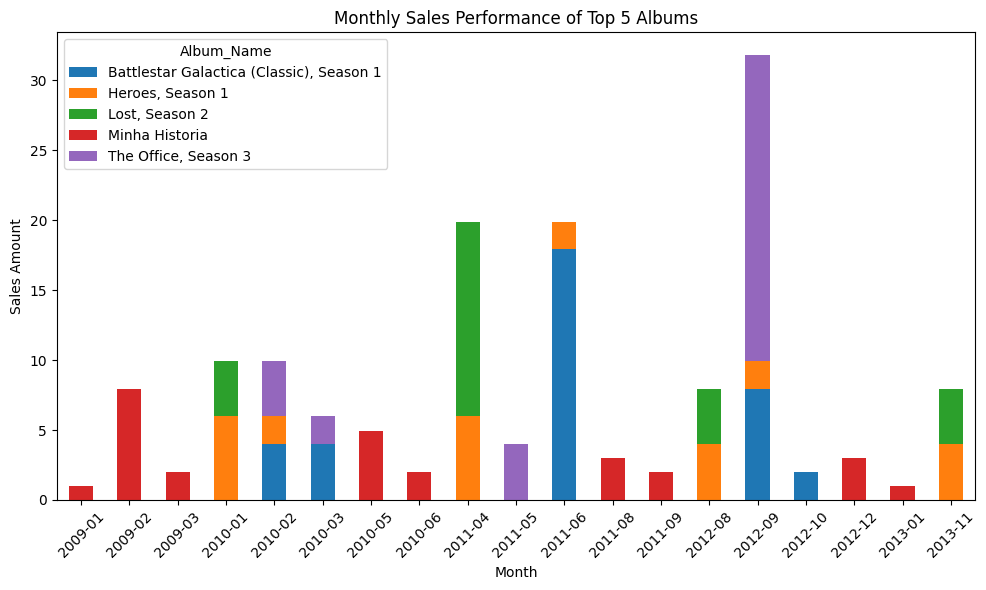

In [14]:

Dataframe['Date'] = pd.to_datetime(Dataframe['Date'])
Dataframe['Month'] = Dataframe['Date'].dt.to_period('M')

# Top 5 albums by total sales
top5_albums = Dataframe.groupby('Album_Name')['Monthly_Sales'].sum().nlargest(5).index
top5_df = Dataframe[Dataframe['Album_Name'].isin(top5_albums)]

monthly_album_sales = top5_df.groupby(['Month', 'Album_Name'])['Monthly_Sales'].sum().unstack().fillna(0)

monthly_album_sales.plot(kind='bar', stacked=True, figsize=(10,6))
plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.title("Monthly Sales Performance of Top 5 Albums")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Dashboard Summary

The analysis of the Chinook music store database reveals the following key performance insights:

1️⃣ Top Revenue-Generating Tracks

The highest revenue-generating tracks include "The Woman King", "The Fix", and "Walkabout".
Each of these tracks generated $3.98 in revenue, indicating consistent pricing and strong purchase demand among top tracks.

2️⃣ Revenue by Country

The USA is the largest market, generating $523.06 in revenue from 91 invoices across 13 customers.
Canada ranks second with $303.96 in revenue, while European countries such as France, Germany, and the UK also contribute significantly.
This suggests that revenue is geographically concentrated in North America, with Europe as a strong secondary market.

3️⃣ Top Performing Artists

Iron Maiden is the highest revenue-generating artist, with $138.60 in total sales across 21 albums.
U2 and Metallica follow as strong contributors.

4️⃣ Revenue by Genre

Genre-level aggregation shows:
Rock – $826.65 (Highest)
Latin – $382.14
Metal – $261.36
Alternative & Punk – $241.56
Rock clearly dominates total revenue contribution in the dataset.

5️⃣ Most Featured Tracks in Playlists

Tracks such as "Ave Maria" and several other compositions appear in up to 5 playlists each, indicating strong playlist presence and potential popularity influence.

6️⃣ Top Selling Albums

"Battlestar Galactica (Classic), Season 1" leads album sales with $35.82 in revenue.
Revenue among the top five albums is relatively competitive, indicating no single album overwhelmingly dominating.

---------------------------------------------------------------------------------------------------------------------

Business Insights

1️⃣ Rock Is the Top Revenue-Contributing Genre

Rock generates the highest total revenue ($826.65), making it the strongest performing genre in the dataset.
The company should continue focusing on Rock music because it playing a major role in overall sales performance.

2️⃣ USA Is the Strongest Market

The USA generates the highest revenue ($523.06) and has the largest number of invoices and customers.
The business should focus marketing campaigns in the USA to maintain and increase sales.

3️⃣ Revenue Is Concentrated Among Top Artists

A small group of artists — including Iron Maiden, U2, and Metallica — contributes a significant share of total revenue so promoting high-performing artists can significantly impact overall sales.

4️⃣ Album-Level Revenue Is Unevenly Distributed

"Battlestar Galactica (Classic), Season 1" is the highest-selling album, outperforming other albums in total sales.
A limited number of albums contribute to album-level revenue. Identifying and promoting high-performing albums can improve profitability.

5️⃣ Playlist Visibility Enhances Track Exposure

Several tracks appear in multiple playlists, increasing their visibility across the platform.
Creating more curated playlists may help boost track popularity and sales.

🎯 Overall Strategic Insight:

Revenue performance is driven primarily by:
The Rock genre
The USA market
A small group of top-performing artists
Focusing on high-performing genres, regions, artists, and albums can maximize revenue growth and strategic decision-making.

---------------------------------------------------------------------------------------------------------------------

Final Analytical Observation

The Chinook dataset demonstrates how relational database design combined with SQL aggregation and Python visualization can transform structured data into actionable business intelligence.

Revenue patterns indicate concentration by genre, geography, and artist — offering clear opportunities for targeted marketing and strategic growth.